<a href="https://colab.research.google.com/github/kowsik005/ml_supervised_project/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (569, 10)

First 5 Rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  
0          0.11840           0.27760          0.3001              0.14710  
1          0.08474           0.07864          0.0869              0.07017  
2          0.10960           0.15990          0.1974              0.12790  
3          0.14250           0.28390          0.2414              0.10520  
4          0.10030           0.13280          0.1980              0.10430  

Dataset Information:
<class 

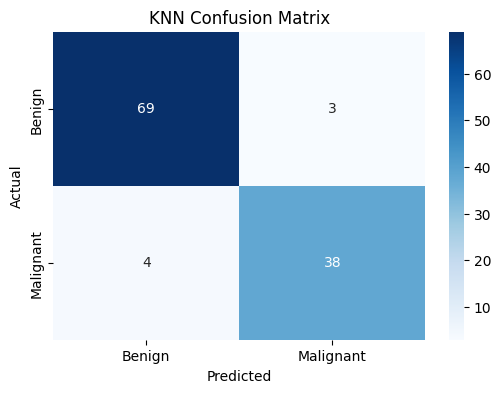


Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      0.96      0.95        72
   Malignant       0.93      0.90      0.92        42

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



In [7]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-Test Split
from sklearn.model_selection import train_test_split

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# KNN Model
from sklearn.neighbors import KNeighborsClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv("KNNAlgorithmDataset-selected-columns.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())


# ============================================================
# 3. CHECK DATASET
# ============================================================

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


# ============================================================
# 4. DEFINE INPUT (X) AND OUTPUT (y)
# ============================================================

# Remove ID because it is not useful for prediction
X = df.drop(columns=["id", "diagnosis"])

# Target variable
y = df["diagnosis"]

print("\nInput Features:")
print(X.columns)

print("\nTarget:")
print(y.name)


# ============================================================
# 5. CONVERT TARGET INTO NUMERIC VALUES
# ============================================================

# B = 0
# M = 1
y = y.map({"B": 0, "M": 1})

print("\nTarget Values:")
print(y.value_counts())


# ============================================================
# 6. SPLIT DATA INTO TRAINING AND TESTING
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


# ============================================================
# 7. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ============================================================
# 8. CREATE KNN MODEL
# ============================================================

knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train, y_train)


# ============================================================
# 9. MAKE PREDICTIONS
# ============================================================

y_pred = knn.predict(X_test)

print("\nPredicted Values:")
print(y_pred)


# ============================================================
# 10. MODEL ACCURACY
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")


# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")

plt.show()


# ============================================================
# 12. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Benign", "Malignant"]
    )
)